In [6]:
from __future__ import annotations

from typing import Optional, Callable, List

import torch
from torch.optim import Optimizer
from torch.optim.lr_scheduler import LRScheduler

In [33]:
class PowerScheduler(LRScheduler):
    def __init__(
        self,
        optimizer,
        batch_size: int,
        *,
        a: float = 4.6,
        b: float = -0.51,
        max_lr: float = 2e-2,
        warmup_tokens: int = 1_000_000_000,
        decay_tokens: int = 0,
        total_tokens: Optional[int] = None,
        decay_fn: Optional[Callable[[int, int, int], float]] = None,
        last_epoch: int = -1, # keeps API parity
    ):
        super().__init__(optimizer, last_epoch)

        if batch_size <= 0:
            raise ValueError("batch_size must be positive")
        if b >= 0:
            raise ValueError("b should be < 0")
        if decay_tokens and total_tokens is None:
            raise ValueError("total_tokens must be provided if decay_tokens > 0.")
        if warmup_tokens < 0 or decay_tokens < 0:
            raise ValueError("warmup_tokens and decay_tokens must be >= 0.")

        if total_tokens is not None and decay_tokens > 0:
            self.decay_start: Optional[int] = total_tokens - decay_tokens
            if self.decay_start <= warmup_tokens:
                raise ValueError("Final-decay window overlaps warm-up. Adjust total_tokens or decay_tokens.")
        else:
            self.decay_start = None

        self.optimizer: Optimizer = optimizer
        self.batch_size: int = batch_size

        self.a: float = a
        self.b: float = b
        self.max_lr: float = max_lr
        self.warmup_tokens: int = warmup_tokens
        self.decay_tokens: int = decay_tokens
        self.total_tokens = total_tokens
        self.decay_fn = decay_fn or self.linear_decay_fn

        self.tokens_trained: int = 0

    def step(self, tokens_trained: Optional[int] = None) -> None:   # type: ignore[override]
        if tokens_trained is None:
            if self._step_count == 0:
                return
            raise TypeError("PowerScheduler.step() requires a 'tokens_trained' argument after initialization.")

        if tokens_trained < self.tokens_trained:
            raise ValueError("tokens_trained must be non-decreasing")
        self.tokens_trained = tokens_trained

        super().step()

    def get_lr(self) -> List[float]:
        tokens_trained = self.tokens_trained
        if tokens_trained < 0:
            raise ValueError("tokens_trained must be >= 0")

        if tokens_trained < self.warmup_tokens:
            lr = tokens_trained / self.warmup_tokens * self._power_lr(self.warmup_tokens)
        elif self.decay_start is None or tokens_trained <= self.decay_start:
            lr = self._power_lr(tokens_trained)
        else:
            if self.total_tokens is None:
                raise ValueError("total_tokens must be provided if decay_tokens > 0.")
            
            lr = self._power_lr(self.decay_start) * self.decay_fn(tokens_trained, self.total_tokens, self.decay_tokens)

        return [min(self.max_lr, lr * (base / self.base_lrs[0])) for base in self.base_lrs]

    def _power_lr(self, n: int) -> float:
        return self.a * self.batch_size * n**self.b

    @staticmethod
    def linear_decay_fn(tokens_trained: int, total_tokens: int, decay_tokens: int) -> float:
        decay_start = total_tokens - decay_tokens
        return max(1.0 - ((tokens_trained - decay_start) / decay_tokens), 0.0)

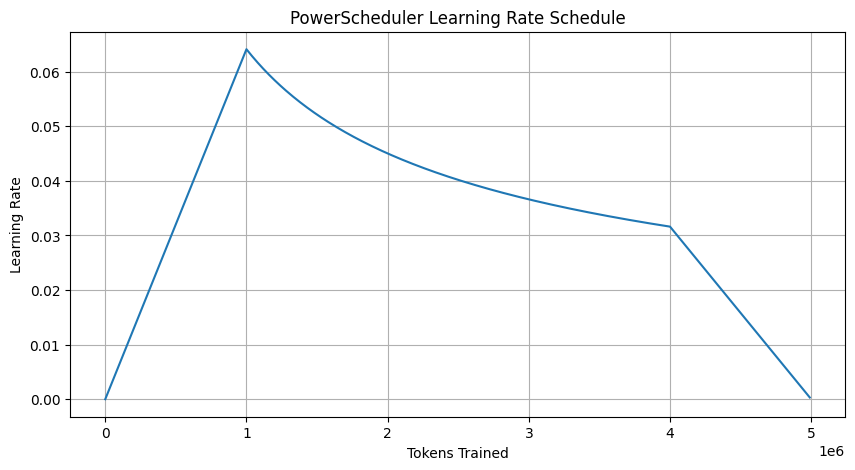

In [ ]:
import matplotlib.pyplot as plt
import torch
from torch.optim import SGD

model = torch.nn.Linear(10, 1)
optimizer = SGD(model.parameters(), lr=0.001)

scheduler = PowerScheduler(
    optimizer=optimizer,
    batch_size=16,
    max_lr=1.0,
    warmup_tokens=1_000_000,
    decay_tokens=1_000_000,
    total_tokens=5_000_000,
)

tokens_range = range(1, 5_000_000, 10000)
lrs = []

for tokens in tokens_range:
    scheduler.step(tokens)
    lrs.append(scheduler.get_lr()[0])

plt.figure(figsize=(10, 5))
plt.plot(tokens_range, lrs)
plt.title("PowerScheduler Learning Rate Schedule")
plt.xlabel("Tokens Trained")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()
